In [1]:
import warnings

import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot

from ccnact import SI, parcel

In [80]:
outputs = {}
for allow_ripening in (True, False):
    out = {}
    _, out["rh"], out["r_w"], out["time"], out["act"] = parcel(
        # updraft and initial thermodynamic state
        w=(updraft := 0.25 * SI.m / SI.s),
        p=1013 * SI.hPa,
        T=300 * SI.K,
        RH=0.99,
        # dry aerosol spectrum
        kappa=(1.2,),
        meanr=(3e-8 * SI.m,),
        gstdv=(1.5,),
        n_tot=(1500 / SI.cm**3,),
        # numerics
        n_bins=100,
        dt=1 * SI.s,
        nt=300,
        allow_ripening=allow_ripening,
        rtol=1e-5,
    )
    outputs[allow_ripening] = out

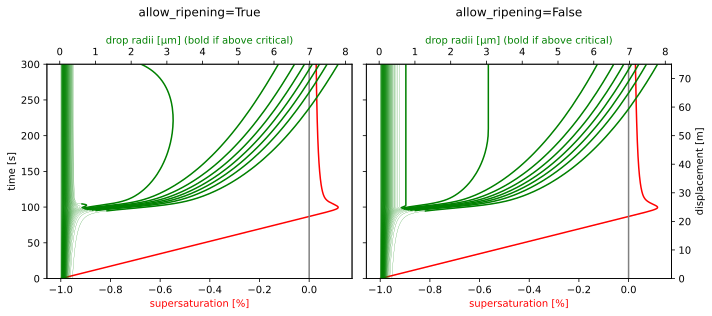

In [81]:
def label_yaxes(ax, axs, output):
    """adds left (time) and right (distance) labels"""
    if ax == axs[0]:
        ax.set(ylabel="time [s]", ylim=(output["time"][0], output["time"][-1]))
    if ax == axs[-1]:
        ax.secondary_yaxis(
            "right",
            functions=(
                lambda t: updraft * t,
                lambda z: z / updraft,
            ),
        ).set_ylabel("displacement [m]")


fig, xys = pyplot.subplots(
    1, 2, figsize=(10, 4.5), sharex=True, sharey=True, tight_layout=True
)
for allow_ripening, out in outputs.items():
    xy1 = xys[int(not allow_ripening)]
    xy2 = xy1.twiny()
    for i in range(out["r_w"].shape[0]):
        xy2.plot(
            out["r_w"][i, :] / SI.um, out["time"], color=(r_color := "green"), lw=0.2
        )
        xy2.plot(
            np.where(out["act"][i, :], out["r_w"][i, :] / SI.um, np.nan),
            out["time"],
            color=r_color,
        )
    xy1.plot((out["rh"] - 1) * 100, out["time"], color=(s_color := "red"))
    xy1.axvline(0, color="gray")
    xy1.set_xlabel("supersaturation [%]", color=s_color)
    xy2.set_xlabel("drop radii [μm] (bold if above critical)", color=r_color)
    label_yaxes(xy1, xys, out)
    xy1.set_title(f"{allow_ripening=}\n")
show_plot("ripening_vs_noripening")

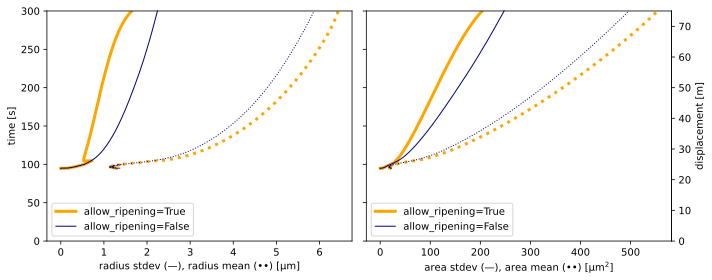

In [82]:
colors = {True: "orange", False: "navy"}

fig, xys = pyplot.subplots(
    1, 2, figsize=(10, 4), sharex=False, sharey=True, tight_layout=True
)
for allow_ripening, out in outputs.items():
    r_act = np.where(out["act"], out["r_w"], np.nan)
    a_act = 4 * np.pi * r_act**2
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", category=RuntimeWarning, message="Mean of empty slice"
        )
        warnings.filterwarnings(
            "ignore",
            category=RuntimeWarning,
            message="Degrees of freedom <= 0 for slice",
        )
        r_act_mean = np.nanmean(r_act, axis=0)
        r_act_stdv = np.nanstd(r_act, axis=0)
        a_act_mean = np.nanmean(a_act, axis=0)
        a_act_stdv = np.nanstd(a_act, axis=0)
    kwargs = {"linewidth": 1 + 2 * allow_ripening, "color": colors[allow_ripening]}
    xys[0].plot(r_act_mean / SI.um, out["time"], linestyle=":", **kwargs)
    xys[0].plot(r_act_stdv / SI.um, out["time"], **kwargs, label=f"{allow_ripening=}")
    xys[1].plot(a_act_mean / SI.um**2, out["time"], linestyle=":", **kwargs)
    xys[1].plot(
        a_act_stdv / SI.um**2, out["time"], **kwargs, label=f"{allow_ripening=}"
    )
for i in (0, 1):
    xys[i].legend()
for xy in xys:
    label_yaxes(xy, xys, out)
xys[0].set_xlabel("radius stdev (—), radius mean (••) [μm]")
xys[1].set_xlabel("area stdev (—), area mean (••) [μm$^2$]")
show_plot("moments")